# Drug Toxicity Prediction using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("tox21.csv")

print("Dataset Loaded")
df.head()

Dataset Loaded


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


Cell 4 – Data Cleaning


In [3]:
# Remove missing values
df = df.dropna()

# Drop non-numeric columns
df = df.drop(columns=["mol_id", "smiles"], errors='ignore')

print("Columns:", df.columns)

Columns: Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53'],
      dtype='object')


Data Analysis

In [4]:
print("Statistical Summary:")
print(df.describe())

print("\nCorrelation:")
print(df.corr())

Statistical Summary:
             NR-AR    NR-AR-LBD       NR-AhR  NR-Aromatase        NR-ER  \
count  3079.000000  3079.000000  3079.000000   3079.000000  3079.000000   
mean      0.019162     0.011043     0.050016      0.017863     0.079247   
std       0.137117     0.104519     0.218014      0.132475     0.270167   
min       0.000000     0.000000     0.000000      0.000000     0.000000   
25%       0.000000     0.000000     0.000000      0.000000     0.000000   
50%       0.000000     0.000000     0.000000      0.000000     0.000000   
75%       0.000000     0.000000     0.000000      0.000000     0.000000   
max       1.000000     1.000000     1.000000      1.000000     1.000000   

         NR-ER-LBD  NR-PPAR-gamma       SR-ARE     SR-ATAD5       SR-HSE  \
count  3079.000000    3079.000000  3079.000000  3079.000000  3079.000000   
mean      0.021760       0.008444     0.063657     0.003573     0.016239   
std       0.145924       0.091519     0.244181     0.059674     0.126414   

Visualization

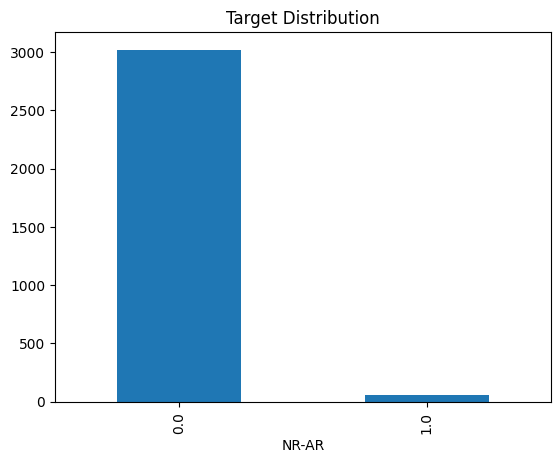

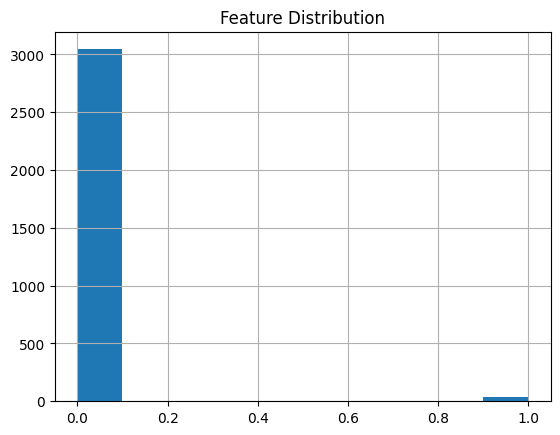

In [5]:
# Target distribution
df.iloc[:,0].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

# Histogram
df.iloc[:,1].hist()
plt.title("Feature Distribution")
plt.show()

Model Training

In [7]:
y = df.iloc[:, 0]
X = df.iloc[:, 1:]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [8]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Model Accuracy:", acc)

Model Accuracy: 0.9805194805194806


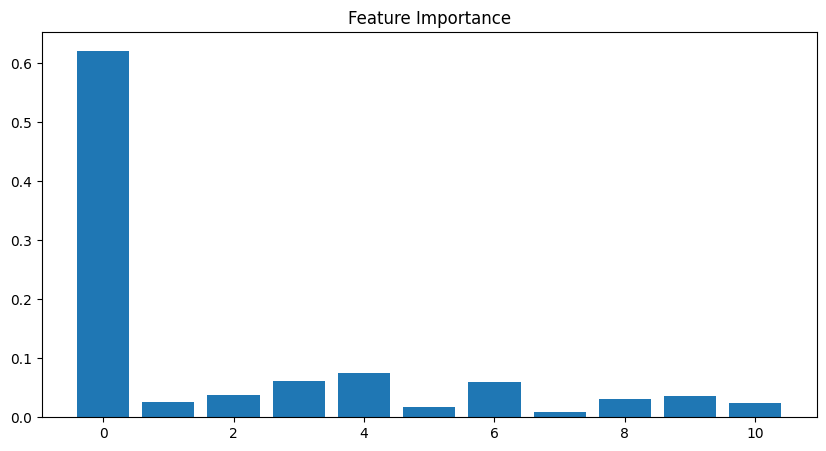

In [9]:
importance = model.feature_importances_

plt.figure(figsize=(10,5))
plt.bar(range(len(importance)), importance)
plt.title("Feature Importance")
plt.show()

In [10]:
print("""
Conclusion:
- Model successfully predicts toxicity
- Certain features strongly influence toxicity
- This can help in drug safety analysis
""")


Conclusion:
- Model successfully predicts toxicity
- Certain features strongly influence toxicity
- This can help in drug safety analysis

